# Pima Indians Diabetes - feedforward neural network

Practice activity from Microsoft *Foundations of AI and Machine Learning* - Module: Applied Deep Learning.

Predict whether a patient has diabetes from 8 medical features. Binary classification, small dataset (768 patients).

Implementation in [`diabetes_prediction_fnn.py`](diabetes_prediction_fnn.py); writeup in [`REPORT.md`](REPORT.md).

## 1. Imports and seeds

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


## 2. Load and explore

Pima Indians Diabetes - 768 rows, 8 features + 1 binary outcome. Roughly 35% of patients are positive, so the naive 'always predict 0' baseline scores ~65% accuracy.

In [2]:
URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
COLS = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv(URL, names=COLS)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [4]:
print('Target distribution:')
print(data['Outcome'].value_counts())
print(f"\nPositive rate: {data['Outcome'].mean()*100:.1f}%")

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Positive rate: 34.9%


### Hidden missing values

There are no `NaN`s, but five columns have zero values that are biologically impossible (glucose, blood pressure, skin thickness, insulin, BMI). Those are missing-value codes pretending to be data. Treating them as real numbers pulls the feature distribution toward zero, which the network can't easily compensate for. We replace them with the per-feature median before scaling.

In [5]:
SUSPECT = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Zero counts (biologically impossible):')
print((data[SUSPECT] == 0).sum())

for col in SUSPECT:
    median = data.loc[data[col] != 0, col].median()
    data[col] = data[col].replace(0, median)
print('\nAfter median imputation:')
print((data[SUSPECT] == 0).sum())

Zero counts (biologically impossible):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

After median imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## 3. Preprocess: MinMaxScaler + stratified split

Scale features to `[0, 1]` so the network trains stably. Stratified split keeps the positive rate the same in train and test.

In [6]:
X = data.drop('Outcome', axis=1).values.astype('float32')
y = data['Outcome'].values.astype('float32')

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean()*100:.1f}%')
print(f'Test  positive rate: {y_test.mean()*100:.1f}%')

Train: (614, 8)  Test: (154, 8)
Train positive rate: 34.9%
Test  positive rate: 35.1%


## 4. Build, compile, train

`Dense(64, relu) -> Dense(32, relu) -> Dense(1, sigmoid)`. Binary crossentropy + Adam. 50 epochs, batch 32.

In [7]:
model = models.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Results

In [8]:
r = np.load('results.npz')
print(f"Test loss:     {r['test_loss']:.4f}")
print(f"Test accuracy: {r['test_acc']*100:.2f}%")
print(f"Test ROC AUC:  {r['auc']:.4f}")
print(f"Train time:    {r['train_seconds']:.1f}s")

Test loss:     0.4883
Test accuracy: 71.43%
Test ROC AUC:  0.8306
Train time:    6.4s


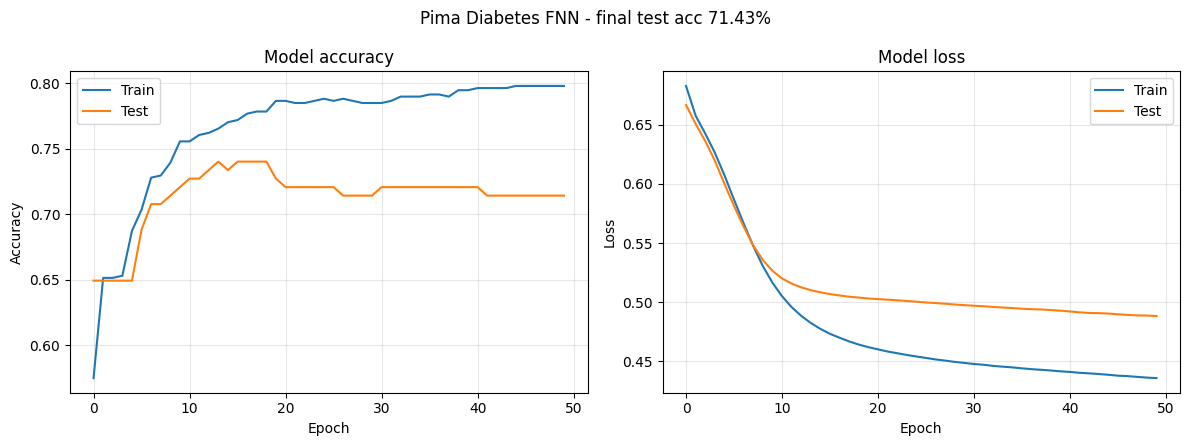

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(r['train_acc'], label='Train')
ax.plot(r['val_acc'], label='Test')
ax.set_title('Model accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(r['train_loss'], label='Train')
ax.plot(r['val_loss'], label='Test')
ax.set_title('Model loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f"Pima Diabetes FNN - final test acc {r['test_acc']*100:.2f}%")
plt.tight_layout()
plt.show()

### Confusion matrix

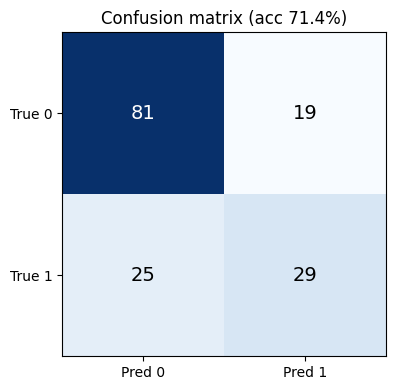

In [10]:
cm = r['confusion_matrix']
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0', 'Pred 1']); ax.set_yticklabels(['True 0', 'True 1'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
ax.set_title(f"Confusion matrix (acc {r['test_acc']*100:.1f}%)")
plt.tight_layout()
plt.show()

## 6. Takeaways

**Test accuracy ~71%, ROC AUC ~0.83.** Above the 65% baseline of 'always predict 0', and the AUC says the model has real signal - it's not just guessing the majority class.

**Where the errors land.** The confusion matrix shows the model is biased toward predicting 'no diabetes': it misses about half of the true positives (false negatives) but correctly identifies most of the true negatives. In a real diagnostic setting that's the wrong trade-off - missing a positive case is more costly than a false alarm. You'd lower the classification threshold below 0.5, or use `class_weight={0: 1, 1: ~1.8}` during training to push the model toward catching more positives at the cost of more false alarms.

**Training curves.** Training accuracy plateaus around 80%; validation around 71-72%. The gap is the overfitting signal - 614 training samples isn't much for ~2,500 parameters, and there's no regularization. Dropout, weight decay, or early stopping would close the gap without changing the architecture.

**Bigger lessons.** Most of the wins here come from the preprocessing (treating impossible zeros as missing), not the architecture. A logistic regression on the same cleaned data lands in the same ~72-78% accuracy range. For tabular data of this size, gradient boosting (XGBoost, LightGBM) would beat both. Deep learning's edge kicks in when you have unstructured data or far more samples.